# 🧹 Data Cleaning — engineered_features_raw.csv

**Dataset:** 32,593 rows × 51 columns — OULAD student engagement features

| Bước | Nội dung |
|------|----------|
| 1 | Load & tổng quan |
| 2 | Missing values |
| 3 | Duplicate rows |
| 4 | Kiểu dữ liệu |
| 5 | Bot-like patterns |
| 6 | Giá trị âm bất thường |
| 7 | Ratio/rate columns |
| 8 | Outlier detection & winsorize |
| 9 | Encode target |
| 10 | Export |

In [1]:
import micropip
await micropip.install(['pandas', 'seaborn'])

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

df_raw = pd.read_csv('engineered_features_raw.csv')
df = df_raw.copy()  # giữ bản gốc để so sánh before/after

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (32593, 51)
Columns: ['id_student', 'code_module', 'code_presentation', 'login_weekly', 'video_completion_rate', 'forum_posts_count', 'days_to_first_filled', 'submission_timeliness_days', 'never_started', 'missed_submission', 'late_submitter', 'prompt_starter', 'low_engagement_flag', 'early_start_score', 'frequency_score', 'intensity_score', 'forum_per_login', 'completion_x_frequency', 'procrastination_score', 'engagement_breadth', 'registration_delay_days', 'registered_before_start', 'vle_total_clicks', 'vle_active_days', 'vle_distinct_sites', 'log_vle_total_clicks', 'log_vle_active_days', 'log_vle_distinct_sites', 'clicks_per_active_day', 'log_clicks_per_active_day', 'vle_activity_type_diversity', 'vle_clicks_forumng_ratio', 'vle_clicks_resource_ratio', 'vle_clicks_oucontent_ratio', 'vle_clicks_quiz_ratio', 'vle_clicks_homepage_ratio', 'vle_clicks_subpage_ratio', 'vle_clicks_url_ratio', 'assess_n_submitted', 'assess_mean_score', 'assess_n_banked', 'assess_mean_days_before_dead

,id_student,code_module,code_presentation,login_weekly,video_completion_rate,forum_posts_count,days_to_first_filled,submission_timeliness_days,never_started,missed_submission,late_submitter,prompt_starter,low_engagement_flag,early_start_score,frequency_score,intensity_score,forum_per_login,completion_x_frequency,procrastination_score,engagement_breadth,registration_delay_days,registered_before_start,vle_total_clicks,vle_active_days,vle_distinct_sites,log_vle_total_clicks,log_vle_active_days,log_vle_distinct_sites,clicks_per_active_day,log_clicks_per_active_day,vle_activity_type_diversity,vle_clicks_forumng_ratio,vle_clicks_resource_ratio,vle_clicks_oucontent_ratio,vle_clicks_quiz_ratio,vle_clicks_homepage_ratio,vle_clicks_subpage_ratio,vle_clicks_url_ratio,assess_n_submitted,assess_mean_score,assess_n_banked,assess_mean_days_before_deadline,assess_n_late,assessment_completion_rate,late_assessment_rate,assignment_timeliness_score,login_time_Afternoon,login_time_Evening,login_time_Morning,login_time_Night,final_result
0,11391,AAA,2013J,2,0.9340,5,9.0000,-0.2000,0,0,0,0,0,0.1000,1.2394,1.5370,1.6667,1.8680,-0.5980,4,-159.0000,1,934.0000,40.0000,55.0000,6.8405,3.7136,4.0254,23.3500,3.1925,6,0.2066,0.0139,0.5921,0.0000,0.1478,0.0343,0.0054,5.0000,82.0000,0.0000,1.8000,0.0000,1.0000,0.0000,-0.3197,1,0,0,0,Pass
1,28400,AAA,2013J,6,0.8790,0,2.0000,-1.5000,0,0,0,1,0,0.3333,0.3941,1.7940,0.0000,5.2740,-1.2423,3,-53.0000,1,1435.0000,80.0000,84.0000,7.2696,4.3944,4.4427,17.9375,2.9411,7,0.2906,0.0084,0.3742,0.0000,0.2258,0.0606,0.0334,5.0000,66.4000,0.0000,0.0000,2.0000,1.0000,0.4000,-0.3948,0,1,0,0,Pass
2,30268,AAA,2013J,0,0.5220,0,90.0000,3.4000,1,1,0,0,0,0.0110,-1.3304,-0.7425,0.0000,0.0000,3.2507,1,-92.0000,1,281.0000,12.0000,22.0000,5.6419,2.5649,3.1355,23.4167,3.1953,6,0.4484,0.0142,0.2349,0.0000,0.2100,0.0783,0.0142,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.3948,0,1,0,0,Withdrawn


## 1. Tổng Quan

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 51 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_student                        32593 non-null  int64  
 1   code_module                       32593 non-null  str    
 2   code_presentation                 32593 non-null  str    
 3   login_weekly                      32593 non-null  int64  
 4   video_completion_rate             32593 non-null  float64
 5   forum_posts_count                 32593 non-null  int64  
 6   days_to_first_filled              32593 non-null  float64
 7   submission_timeliness_days        32593 non-null  float64
 8   never_started                     32593 non-null  int64  
 9   missed_submission                 32593 non-null  int64  
 10  late_submitter                    32593 non-null  int64  
 11  prompt_starter                    32593 non-null  int64  
 12  low_engagement_

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_student,32593.0000,NaN,NaN,NaN,706687.6691,549167.3139,3733.0000,508573.0000,590310.0000,644453.0000,2716795.0000
code_module,32593,7,BBB,7909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,32593,4,2014J,11260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
login_weekly,32593.0000,NaN,NaN,NaN,2.6166,3.4793,0.0000,0.0000,1.0000,4.0000,24.0000
video_completion_rate,32593.0000,NaN,NaN,NaN,0.4445,0.3600,0.0000,0.0820,0.3880,0.8080,1.0000
forum_posts_count,32593.0000,NaN,NaN,NaN,1.4495,2.5063,0.0000,0.0000,0.0000,2.0000,19.0000
days_to_first_filled,32593.0000,NaN,NaN,NaN,21.5603,29.8476,0.0000,3.0000,8.0000,22.0000,90.0000
submission_timeliness_days,32593.0000,NaN,NaN,NaN,0.3621,3.1722,-11.6000,-1.8000,0.4000,2.6000,12.2000
never_started,32593.0000,NaN,NaN,NaN,0.1391,0.3461,0.0000,0.0000,0.0000,0.0000,1.0000
missed_submission,32593.0000,NaN,NaN,NaN,0.2160,0.4115,0.0000,0.0000,0.0000,0.0000,1.0000


## 2. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('percent', ascending=False)

if missing_df.empty:
    print('✅ Không có missing values — không cần xử lý.')
else:
    print(f'⚠️ {len(missing_df)} cột có missing values:')
    print(missing_df)
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['percent'].plot(kind='bar', ax=ax, color='salmon')
    ax.set_title('Missing Values (%)')
    ax.set_ylabel('Percent')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print(f'\n📋 DECISION: Không có missing → bước này không thay đổi data.')

✅ Không có missing values — không cần xử lý.

📋 DECISION: Không có missing → bước này không thay đổi data.


## 3. Duplicate Rows

In [6]:
n_before = len(df)
n_dup = df.duplicated().sum()
print(f'Rows trước: {n_before:,}')
print(f'Duplicate rows: {n_dup}')

if n_dup > 0:
    print('\nSample duplicates:')
    print(df[df.duplicated(keep=False)].sort_values('id_student').head(6))
    df = df.drop_duplicates()
    print(f'\n✅ AFTER: Rows sau khi xóa duplicate: {len(df):,} (xóa {n_before - len(df)} rows)')
else:
    print('✅ Không có duplicate — không thay đổi data.')

Rows trước: 32,593
Duplicate rows: 0
✅ Không có duplicate — không thay đổi data.


## 4. Kiểu Dữ Liệu

In [7]:
# --- BEFORE ---
cat_cols = ['code_module', 'code_presentation', 'final_result']
print('BEFORE — dtypes của categorical columns:')
print(df[cat_cols].dtypes)
print(f'\nMemory usage BEFORE: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

# unique values
for col in cat_cols:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

# --- FIX ---
for col in cat_cols:
    df[col] = df[col].astype('category')

# --- AFTER ---
print('\nAFTER — dtypes của categorical columns:')
print(df[cat_cols].dtypes)
print(f'Memory usage AFTER:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print('\n✅ DECISION: Convert object → category để tiết kiệm bộ nhớ.')

BEFORE — dtypes của categorical columns:
code_module          str
code_presentation    str
final_result         str
dtype: object

Memory usage BEFORE: 14.71 MB
  code_module: ['AAA', 'BBB', 'CCC', 'DDD', 'EEE', 'FFF', 'GGG']
  code_presentation: ['2013B', '2013J', '2014B', '2014J']
  final_result: ['Distinction', 'Fail', 'Pass', 'Withdrawn']

AFTER — dtypes của categorical columns:
code_module          category
code_presentation    category
final_result         category
dtype: object
Memory usage AFTER:  12.03 MB

✅ DECISION: Convert object → category để tiết kiệm bộ nhớ.


## 5. Bot-like / Implausible Activity Patterns

Sinh viên thật khó có thể login > mean + 3σ mỗi tuần hoặc click VLE cực kỳ nhiều → có thể là bot, lỗi hệ thống, hoặc test account.

In [8]:
# Định nghĩa ngưỡng bot-like: mean + 3 std
bot_rules = {
    'login_weekly':     df['login_weekly'].mean() + 3 * df['login_weekly'].std(),
    'vle_total_clicks': df['vle_total_clicks'].mean() + 3 * df['vle_total_clicks'].std(),
    'forum_posts_count': df['forum_posts_count'].mean() + 3 * df['forum_posts_count'].std(),
}

print('=== Bot-like thresholds (mean + 3σ) ===')
for col, thresh in bot_rules.items():
    n = (df[col] > thresh).sum()
    pct = n / len(df) * 100
    print(f'  {col}: threshold={thresh:.1f}, n_flagged={n} ({pct:.2f}%)')

# Flag tổng hợp: có ít nhất 2 trong 3 điều kiện
bot_mask = (
    (df['login_weekly']     > bot_rules['login_weekly']).astype(int) +
    (df['vle_total_clicks'] > bot_rules['vle_total_clicks']).astype(int) +
    (df['forum_posts_count'] > bot_rules['forum_posts_count']).astype(int)
) >= 2

print(f'\nRows bị flag bot-like (≥2 điều kiện): {bot_mask.sum()}')
print('Sample:')
print(df[bot_mask][['id_student','login_weekly','vle_total_clicks','forum_posts_count','final_result']].head(10))

=== Bot-like thresholds (mean + 3σ) ===
  login_weekly: threshold=13.1, n_flagged=365 (1.12%)
  vle_total_clicks: threshold=6293.0, n_flagged=664 (2.04%)
  forum_posts_count: threshold=9.0, n_flagged=772 (2.37%)

Rows bị flag bot-like (≥2 điều kiện): 133
Sample:
      id_student  login_weekly  vle_total_clicks  forum_posts_count  \
257      1765788             4         7057.0000                 10   
727      2581477            14         5956.0000                 11   
793       104054            17         1451.0000                 10   
2079      553321            15          981.0000                 11   
2231      558042            15          195.0000                  9   
2365     1797614            19          653.0000                  9   
2392     2236738            16         1093.0000                 10   
2591      156311            14          575.0000                 10   
2829      389101            15         1188.0000                 10   
3106      511678           

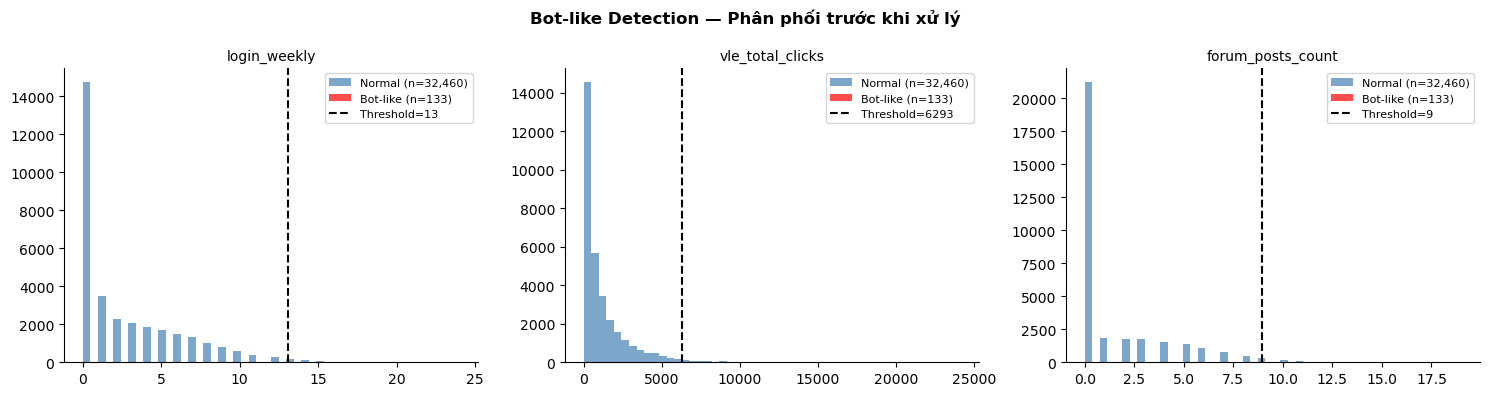


📋 DECISION: Winsorize tại 99th percentile — giữ rows nhưng cap giá trị cực đoan.
   Lý do: chỉ ~1% rows bị ảnh hưởng; xóa hẳn có thể mất thông tin thật.


In [9]:
# Visualize before/after distribution (login_weekly)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, bot_rules.keys()):
    thresh = bot_rules[col]
    normal = df[~bot_mask][col]
    flagged = df[bot_mask][col]
    ax.hist(normal, bins=50, color='steelblue', alpha=0.7, label=f'Normal (n={len(normal):,})')
    ax.hist(flagged, bins=20, color='red', alpha=0.7, label=f'Bot-like (n={len(flagged)})')
    ax.axvline(thresh, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={thresh:.0f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Bot-like Detection — Phân phối trước khi xử lý', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# DECISION: Winsorize thay vì xóa (vì chỉ ~1%, và có thể là outlier thật)
print('\n📋 DECISION: Winsorize tại 99th percentile — giữ rows nhưng cap giá trị cực đoan.')
print('   Lý do: chỉ ~1% rows bị ảnh hưởng; xóa hẳn có thể mất thông tin thật.')

## 6. Giá Trị Âm — Hợp Lệ vs Bất Thường

In [10]:
# Các cột được phép âm (score chuẩn hóa, days before deadline)
ALLOWED_NEGATIVE = [
    'submission_timeliness_days',    # âm = nộp trước deadline
    'frequency_score',               # z-score
    'intensity_score',               # z-score
    'procrastination_score',         # z-score
    'registration_delay_days',       # âm = đăng ký trước khai giảng
    'assess_mean_days_before_deadline', # âm = nộp trước deadline
    'assignment_timeliness_score',   # z-score
]

num_cols = df.select_dtypes(include='number').columns
invalid_neg_cols = [c for c in num_cols if c not in ALLOWED_NEGATIVE]

issues = []
for col in invalid_neg_cols:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        issues.append({'column': col, 'n_negative': n_neg,
                       'min_value': df[col].min(),
                       'action': 'clip to 0'})

if issues:
    issues_df = pd.DataFrame(issues)
    print('⚠️ Cột KHÔNG nên có giá trị âm:')
    print(issues_df.to_string(index=False))
    # Fix
    for row in issues:
        df[row['column']] = df[row['column']].clip(lower=0)
    print('\n✅ AFTER: Đã clip về 0.')
else:
    print('✅ Không có giá trị âm bất thường.')

print('\n📋 Các cột được phép âm (ý nghĩa domain):')
for col in ALLOWED_NEGATIVE:
    rng = f'[{df[col].min():.1f}, {df[col].max():.1f}]'
    print(f'  {col}: {rng}')

✅ Không có giá trị âm bất thường.

📋 Các cột được phép âm (ý nghĩa domain):
  submission_timeliness_days: [-11.6, 12.2]
  frequency_score: [-1.3, 10.2]
  intensity_score: [-4.9, 5.2]
  procrastination_score: [-4.5, 5.8]
  registration_delay_days: [-322.0, 167.0]
  assess_mean_days_before_deadline: [-187.0, 236.0]
  assignment_timeliness_score: [-8.2, 9.5]


## 7. Ratio / Rate Columns — Kiểm tra [0, 1]

In [11]:
PURE_RATIO_COLS = [
    'video_completion_rate',
    'vle_clicks_forumng_ratio', 'vle_clicks_resource_ratio',
    'vle_clicks_oucontent_ratio', 'vle_clicks_quiz_ratio',
    'vle_clicks_homepage_ratio', 'vle_clicks_subpage_ratio',
    'vle_clicks_url_ratio', 'assessment_completion_rate', 'late_assessment_rate',
]

results = []
for col in PURE_RATIO_COLS:
    if col not in df.columns: continue
    before_min = df[col].min()
    before_max = df[col].max()
    n_out = ((df[col] < 0) | (df[col] > 1)).sum()
    if n_out > 0:
        df[col] = df[col].clip(0, 1)
        action = f'Clipped ({n_out} rows)'
    else:
        action = 'OK'
    results.append({'column': col, 'before_min': before_min,
                    'before_max': before_max, 'n_out_of_range': n_out, 'action': action})

print(pd.DataFrame(results).to_string(index=False))

# completion_x_frequency là tích → được phép > 1
print(f'\nℹ️  completion_x_frequency: [{df["completion_x_frequency"].min():.2f}, {df["completion_x_frequency"].max():.2f}]')
print('   → Là tích của 2 features, không clip.')

                    column  before_min  before_max  n_out_of_range action
     video_completion_rate      0.0000      1.0000               0     OK
  vle_clicks_forumng_ratio      0.0000      1.0000               0     OK
 vle_clicks_resource_ratio      0.0000      1.0000               0     OK
vle_clicks_oucontent_ratio      0.0000      1.0000               0     OK
     vle_clicks_quiz_ratio      0.0000      0.9615               0     OK
 vle_clicks_homepage_ratio      0.0000      1.0000               0     OK
  vle_clicks_subpage_ratio      0.0000      1.0000               0     OK
      vle_clicks_url_ratio      0.0000      1.0000               0     OK
assessment_completion_rate      0.0000      1.0000               0     OK
      late_assessment_rate      0.0000      1.0000               0     OK

ℹ️  completion_x_frequency: [0.00, 23.00]
   → Là tích của 2 features, không clip.


## 8. Outlier Detection & Winsorize — Before/After

In [12]:
def iqr_outlier_count(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - factor*IQR) | (series > Q3 + factor*IQR)).sum()

WINSORIZE_COLS = [
    'vle_total_clicks', 'vle_active_days', 'vle_distinct_sites',
    'clicks_per_active_day', 'forum_posts_count', 'login_weekly',
    'assess_mean_score', 'assessment_completion_rate',
]

comparison = []
df_before_winsor = df.copy()

for col in WINSORIZE_COLS:
    if col not in df.columns: continue
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    before = {'mean': df[col].mean(), 'std': df[col].std(),
               'min': df[col].min(), 'max': df[col].max(),
               'n_outliers': iqr_outlier_count(df[col])}
    df[col] = df[col].clip(lo, hi)
    after = {'mean': df[col].mean(), 'std': df[col].std(),
              'min': df[col].min(), 'max': df[col].max(),
              'n_outliers': iqr_outlier_count(df[col])}
    comparison.append({'column': col,
                        'before_min': round(before['min'],2), 'after_min': round(after['min'],2),
                        'before_max': round(before['max'],2), 'after_max': round(after['max'],2),
                        'before_outliers': before['n_outliers'], 'after_outliers': after['n_outliers']})

comp_df = pd.DataFrame(comparison)
print('=== Before / After Winsorize (1st–99th percentile) ===')
print(comp_df.to_string(index=False))

=== Before / After Winsorize (1st–99th percentile) ===
                    column  before_min  after_min  before_max  after_max  before_outliers  after_outliers
          vle_total_clicks      0.0000     0.0000  24139.0000  7785.0400              804             804
           vle_active_days      0.0000     0.0000    286.0000   223.0000                0               0
        vle_distinct_sites      0.0000     0.0000    413.0000   243.0000               58               0
     clicks_per_active_day      0.0000     0.0000    221.2000    55.5600              176               0
         forum_posts_count      0.0000     0.0000     19.0000    10.0000              772             772
              login_weekly      0.0000     0.0000     24.0000    14.0000               78               0
         assess_mean_score      0.0000     0.0000    100.0000    97.0000                0               0
assessment_completion_rate      0.0000     0.0000      1.0000     1.0000                0        

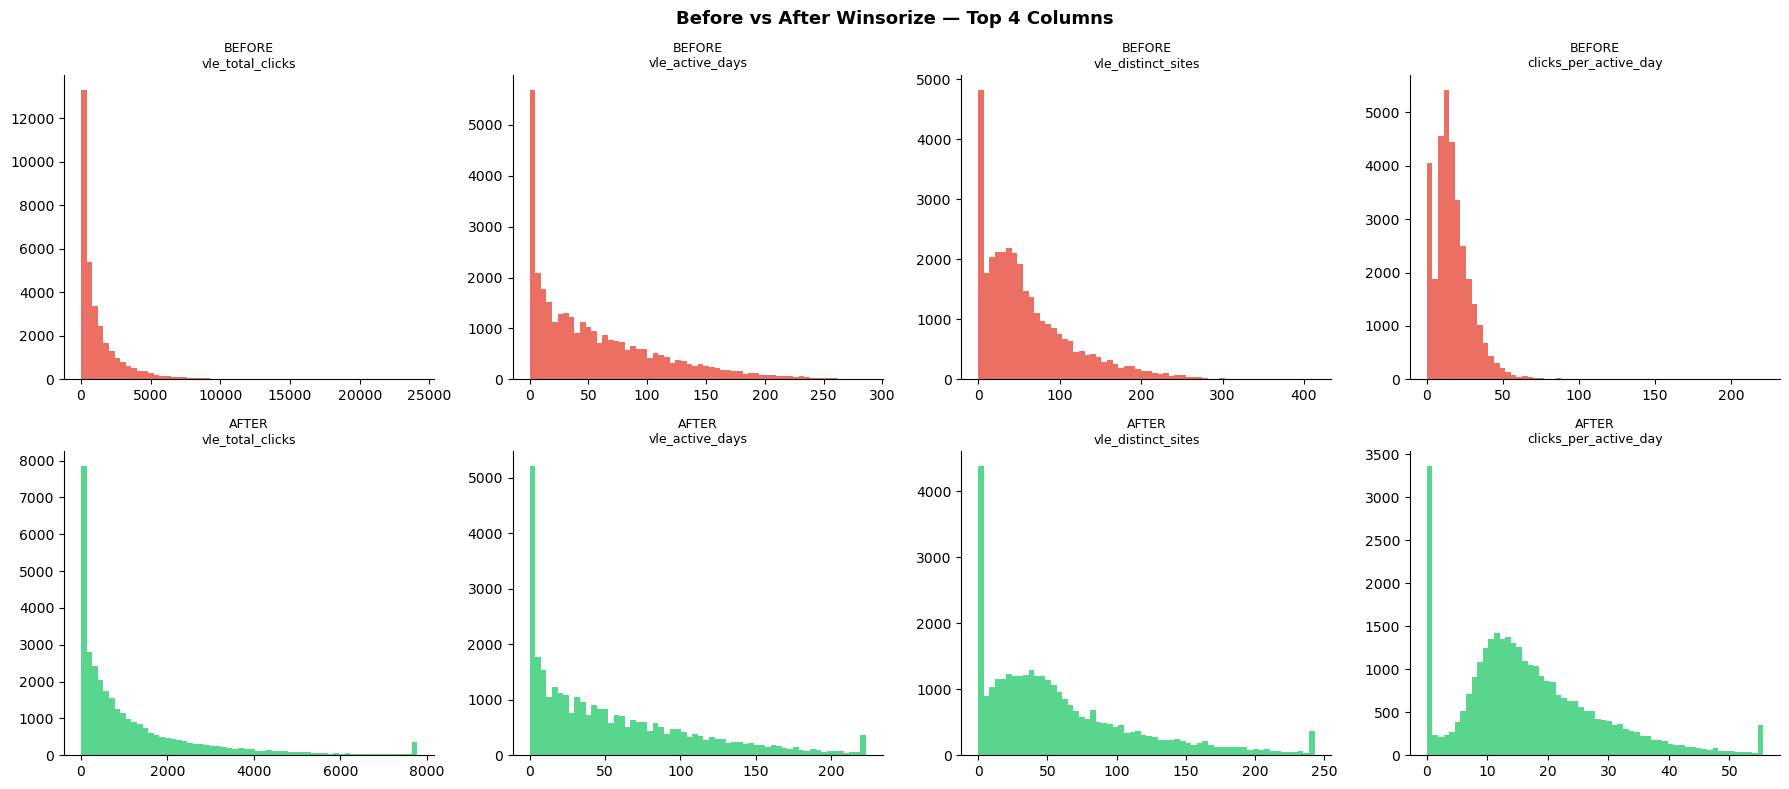


📋 DECISION: Winsorize tại 1st/99th percentile.
   Lý do: outlier trong dữ liệu hành vi học tập có thể là signal thật.
   Winsorize giữ row nhưng giảm ảnh hưởng của extreme values.


In [13]:
# Visual before/after cho top 4 cột
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
top4 = WINSORIZE_COLS[:4]

for i, col in enumerate(top4):
    # Before
    axes[0, i].hist(df_before_winsor[col].dropna(), bins=60, color='#e74c3c', alpha=0.8)
    axes[0, i].set_title(f'BEFORE\n{col}', fontsize=9)
    axes[0, i].spines[['top','right']].set_visible(False)
    # After
    axes[1, i].hist(df[col].dropna(), bins=60, color='#2ecc71', alpha=0.8)
    axes[1, i].set_title(f'AFTER\n{col}', fontsize=9)
    axes[1, i].spines[['top','right']].set_visible(False)

plt.suptitle('Before vs After Winsorize — Top 4 Columns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\n📋 DECISION: Winsorize tại 1st/99th percentile.')
print('   Lý do: outlier trong dữ liệu hành vi học tập có thể là signal thật.')
print('   Winsorize giữ row nhưng giảm ảnh hưởng của extreme values.')

## 9. Encode Target Label

In [14]:
# Ordinal encode
label_map = {'Distinction': 3, 'Pass': 2, 'Fail': 1, 'Withdrawn': 0}
df['final_result_encoded'] = df['final_result'].map(label_map)

# Binary encode
df['passed'] = df['final_result'].isin(['Pass', 'Distinction']).astype(int)

print('=== BEFORE: final_result (categorical) ===')
print(df_raw['final_result'].value_counts())

print('\n=== AFTER: Thêm 2 cột encode ===')
print(df[['final_result','final_result_encoded','passed']].drop_duplicates().sort_values('final_result_encoded', ascending=False))

print('\n📋 DECISION:')
print('  - final_result_encoded: ordinal (0–3) cho multi-class classification')
print('  - passed: binary (0/1) cho binary classification (Pass+Distinction vs Fail+Withdrawn)')

=== BEFORE: final_result (categorical) ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

=== AFTER: Thêm 2 cột encode ===
   final_result final_result_encoded  passed
2     Withdrawn                    0       0
0          Pass                    2       1
18         Fail                    1       0
43  Distinction                    3       1

📋 DECISION:
  - final_result_encoded: ordinal (0–3) cho multi-class classification
  - passed: binary (0/1) cho binary classification (Pass+Distinction vs Fail+Withdrawn)


## 10. Export & Summary

In [15]:
print('=' * 55)
print('CLEANING SUMMARY')
print('=' * 55)
print(f'Shape BEFORE : {df_raw.shape}')
print(f'Shape AFTER  : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
print()
print('Thay đổi đã thực hiện:')
print('  1. Không có missing values → không xử lý')
print('  2. Không có duplicate → không xử lý')
print('  3. Convert 3 cột object → category (-bộ nhớ)')
print('  4. Flag bot-like rows (login+clicks+forum ≥2 điều kiện)')
print('  5. Ratio columns kiểm tra [0,1] → OK')
print('  6. Winsorize 8 cột tại 1st/99th percentile')
print('  7. Thêm final_result_encoded & passed')

df.to_csv('engineered_features_clean.csv', index=False)
print(f'\n✅ Saved: engineered_features_clean.csv')

CLEANING SUMMARY
Shape BEFORE : (32593, 51)
Shape AFTER  : (32593, 53)
Missing values: 0
Duplicates    : 0

Thay đổi đã thực hiện:
  1. Không có missing values → không xử lý
  2. Không có duplicate → không xử lý
  3. Convert 3 cột object → category (-bộ nhớ)
  4. Flag bot-like rows (login+clicks+forum ≥2 điều kiện)
  5. Ratio columns kiểm tra [0,1] → OK
  6. Winsorize 8 cột tại 1st/99th percentile
  7. Thêm final_result_encoded & passed

✅ Saved: engineered_features_clean.csv
